# Taller de Probabilidad e Inferencia Estadistica
## Analisis de la Desercion Laboral — IBM HR Analytics Employee Attrition
### Curso de Estadistica para Ciencia de Datos – SANTO TOMAS
---
**Dataset:** IBM HR Analytics Employee Attrition & Performance  
**Registros:** 1 470 empleados | Variables demograficas, laborales y de satisfaccion  
**Variable objetivo:** `Attrition` (Yes / No)  
**Herramientas:** Python, Pandas, NumPy, SciPy, Matplotlib, Seaborn

**Nuestro objetivo:** Queremos entender como se conectan los datos con decisiones reales de RRHH


## Índice general
1. Introducción y contexto del problema
2. Tablas de contingencia y probabilidades
3. Regla de la probabilidad total
4. Teorema de Bayes
5. Teorema del límite central
6. Estimación puntual de parámetros
7. Intervalos de confianza
8. Pruebas de hipótesis
9. Estimación Bootstrap
10. Resumen de fórmulas clave
11. Referencias

## Configuracion e Importacion de Librerias

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, chi2_contingency, ttest_ind
import warnings
warnings.filterwarnings('ignore')

# Estilo visual
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})ß


Librerias cargadas correctamente


---
## 1. Introduccion y Contexto del Problema

La **desercion laboral** es uno de los problemas mas costosos para las organizaciones modernas.  
Reemplazar a un empleado puede costar entre el **50% y el 200%** de su salario anual.

Utilizaremos el dataset *IBM HR Analytics Employee Attrition & Performance* con **1 470 empleados** y **35 variables**.

### 1.2 Carga del Dataset

> **Nota:** Si tienes el archivo original de Kaggle (`WA_Fn-UseC_-HR-Employee-Attrition.csv`),  
> colocalo en la misma carpeta que este notebook. El codigo lo cargara automaticamente.


### 1.1 Variables principales

| Variable | Tipo | Descripción |
|---|---|---|
| Attrition | Categórica | ¿Dejó la empresa? (Yes/No) |
| Department | Categórica | Departamento: HR, R&D, Sales |
| OverTime | Categórica | Horas extra (Yes/No) |
| Gender | Categórica | Género del empleado |
| MonthlyIncome | Numérica | Ingreso mensual (USD) |
| Age | Numérica | Edad |
| YearsAtCompany | Numérica | Años en la empresa |
| JobSatisfaction | Ordinal | Satisfacción laboral (1–4) |
| DistanceFromHome | Numérica | Distancia al trabajo (km) |

In [102]:
import os

CSV_PATH = "../input/WA_Fn-UseC_-HR-Employee-Attrition.csv"

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(
        "No se encontro el archivo en ../input/. "
        "Coloca 'WA_Fn-UseC_-HR-Employee-Attrition.csv' en la carpeta input."
    )

df = pd.read_csv(CSV_PATH)
print(f"Dataset cargado desde archivo: {CSV_PATH}")

print(f"\nDimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
df.head()

Dataset cargado desde archivo: ../input/WA_Fn-UseC_-HR-Employee-Attrition.csv

Dimensiones: 1470 filas × 35 columnas


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [103]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [104]:
df[df.isnull().any(axis=1)]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager


Los datos no tienen valores nulos, procederemos con la exploración

---
## Tarea 1 — Exploracion Inicial
**a)** Dimensiones del dataset  
**b)** Distribucion de frecuencias de `Attrition`  
**c)** ?Balanceada o desbalanceada?


             Dimensiones del Dataset              
Filas    (empleados) :   1470
Columnas (variables) :     35

            Distribucion de Attrition             
           Frecuencia Absoluta  Frecuencia Relativa  Porcentaje (%)
Attrition                                                          
No                        1233               0.8388           83.88
Yes                        237               0.1612           16.12

Esperamos una distribucion desbalanceada, con mas empleados que NO abandonan (No) que los que SI abandonan (Yes).
Lo vamos a notar facilmente en el grafico de barras y pastel a continuacion.


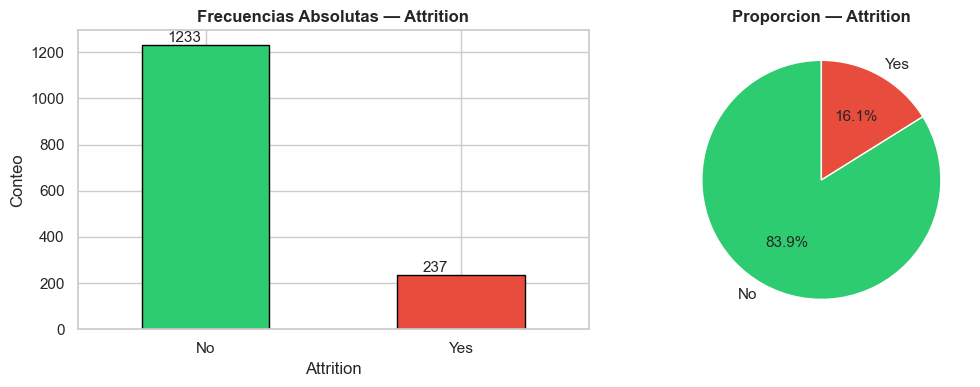


CONCLUSION:
  La distribucion es DESBALANCEADA:
  - 'No'  = 83.9%  →  clase mayoritaria
  - 'Yes' = 16.1%  →  clase minoritaria
No sorprende, ya que la mayoria de empleados suelen quedarse en la empresa. Es lo mas comun.
En terminos de gestion, la clase minoritaria merece atencion porque es la que mas costo genera.


In [105]:
# a) Dimensiones
print("=" * 50)
print(f"{'Dimensiones del Dataset':^50}")
print("=" * 50)
print(f"Filas    (empleados) : {df.shape[0]:>6}")
print(f"Columnas (variables) : {df.shape[1]:>6}")

# b) Frecuencias absolutas y relativas de Attrition
print("\n" + "=" * 50)
print(f"{'Distribucion de Attrition':^50}")
print("=" * 50)
freq_abs = df['Attrition'].value_counts()
freq_rel = df['Attrition'].value_counts(normalize=True)
freq_df = pd.DataFrame({'Frecuencia Absoluta': freq_abs,
                        'Frecuencia Relativa': freq_rel.round(4),
                        'Porcentaje (%)': (freq_rel * 100).round(2)})
print(freq_df.to_string())

print("\nEsperamos una distribucion desbalanceada, con mas empleados que NO abandonan (No) que los que SI abandonan (Yes).")
print("Lo vamos a notar facilmente en el grafico de barras y pastel a continuacion.")
# Grafico
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
freq_abs.plot(kind='bar', ax=axes[0], color=['#2ecc71','#e74c3c'], edgecolor='black')
axes[0].set_title("Frecuencias Absolutas — Attrition", fontweight='bold')
axes[0].set_xlabel("Attrition"); axes[0].set_ylabel("Conteo")
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x()+0.1, p.get_height()+10))

axes[1].pie(freq_abs, labels=freq_abs.index, autopct='%1.1f%%',
            colors=['#2ecc71','#e74c3c'], startangle=90)
axes[1].set_title("Proporcion — Attrition", fontweight='bold')
plt.tight_layout(); plt.show()

# c) Conclusion
print("\nCONCLUSION:")
print(f"  La distribucion es DESBALANCEADA:")
print(f"  - 'No'  = {freq_rel['No']:.1%}  →  clase mayoritaria")
print(f"  - 'Yes' = {freq_rel['Yes']:.1%}  →  clase minoritaria")
print("No sorprende, ya que la mayoria de empleados suelen quedarse en la empresa. Es lo mas comun.")
print("En terminos de gestion, la clase minoritaria merece atencion porque es la que mas costo genera.")


**Implicaciones del desbalance para clasificación**
- La clase minoritaria (Attrition=Yes) puede quedar subrepresentada, y la exactitud global puede ser engañosa.
- Conviene reportar métricas sensibles al desbalance: recall, precision, F1 y curva PR.
- Es útil evaluar con validación estratificada y, si aplica, usar `class_weight`, submuestreo o sobremuestreo.
- En la práctica, el costo de falsos negativos suele ser alto (no detectar riesgo de deserción).

---
## 2. Tablas de Contingencia y Probabilidades

> **Recordatorio de fórmulas**  
> - Probabilidad conjunta: $P(A \cap B) = n(A \cap B)/N$  
> - Probabilidad marginal: $P(A) = \sum_j P(A \cap B_j)$  
> - Probabilidad condicional: $P(A|B) = P(A \cap B)/P(B)$


### Tarea 2 — OverTime vs. Attrition


In [106]:
print("=" * 55)
print("Vamos a calcular la tabla de contingencia entre OverTime y Attrition, y luego las probabilidades conjuntas.")
print("OverTime es una variable que indica si el empleado hace horas extras (Yes) o no (No).")
print("Attrition es la variable objetivo que indica si el empleado abandono la empresa (Yes) o no (No).")
print("\n")

N = len(df)

# a) Tabla de contingencia con totales marginales
tabla_OT = pd.crosstab(df['OverTime'], df['Attrition'], margins=True, margins_name='Total')
print("=" * 55)
print("TABLA DE CONTINGENCIA: OverTime vs. Attrition")
print("=" * 55)
print(tabla_OT)

# b) Probabilidades conjuntas
tabla_joint = pd.crosstab(df['OverTime'], df['Attrition'], normalize='all').round(4)
tabla_joint['Marginal_fila'] = tabla_joint.sum(axis=1)
print("\n" + "=" * 55)
print("PROBABILIDADES CONJUNTAS P(OT, Att)")
print("=" * 55)
print(tabla_joint)
print(f"\nMarginal columna (No, Yes):  {tabla_joint['No'].sum():.4f},  {tabla_joint['Yes'].sum():.4f}")
print(f"Suma total marginal fila:  {tabla_joint['Marginal_fila'].sum():.4f}")


Vamos a calcular la tabla de contingencia entre OverTime y Attrition, y luego las probabilidades conjuntas.
OverTime es una variable que indica si el empleado hace horas extras (Yes) o no (No).
Attrition es la variable objetivo que indica si el empleado abandono la empresa (Yes) o no (No).


TABLA DE CONTINGENCIA: OverTime vs. Attrition
Attrition    No  Yes  Total
OverTime                   
No          944  110   1054
Yes         289  127    416
Total      1233  237   1470

PROBABILIDADES CONJUNTAS P(OT, Att)
Attrition      No     Yes  Marginal_fila
OverTime                                
No         0.6422  0.0748          0.717
Yes        0.1966  0.0864          0.283

Marginal columna (No, Yes):  0.8388,  0.1612
Suma total marginal fila:  1.0000


In [107]:
# c) Probabilidades marginales
p_ott_yes = (df['OverTime']=='Yes').mean()
p_ott_no  = (df['OverTime']=='No').mean()
p_att_yes = (df['Attrition']=='Yes').mean()
p_att_no  = (df['Attrition']=='No').mean()

print("PROBABILIDADES MARGINALES")
print(f"  P(OT=Yes)  = {p_ott_yes:.4f}")
print(f"  P(OT=No)   = {p_ott_no:.4f}   →  Suma OT: {p_ott_yes+p_ott_no:.4f}")
print(f"  P(Att=Yes) = {p_att_yes:.4f}")
print(f"  P(Att=No)  = {p_att_no:.4f}  →  Suma Att: {p_att_yes+p_att_no:.4f}")

# d) Probabilidades condicionales
n_ot_yes = (df['OverTime']=='Yes').sum()
n_ot_no  = (df['OverTime']=='No').sum()
n_att_yes_ot_yes = ((df['OverTime']=='Yes') & (df['Attrition']=='Yes')).sum()
n_att_yes_ot_no  = ((df['OverTime']=='No')  & (df['Attrition']=='Yes')).sum()

p_att_yes_given_ot_yes = n_att_yes_ot_yes / n_ot_yes
p_att_yes_given_ot_no  = n_att_yes_ot_no  / n_ot_no

print("\nPROBABILIDADES CONDICIONALES")
print(f"  P(Att=Yes | OT=Yes) = {p_att_yes_given_ot_yes:.4f}")
print(f"  P(Att=Yes | OT=No)  = {p_att_yes_given_ot_no:.4f}")
print(f"  P(Att=Yes)           = {p_att_yes:.4f}  (marginal)")
print("\nCONCLUSION:")
if p_att_yes_given_ot_yes > p_att_yes:
    print(f"  Las horas extra influyen: P(Att|OT=Yes)={p_att_yes_given_ot_yes:.4f} > P(Att)={p_att_yes:.4f}")
    print("  Hacer horas extra aumenta la probabilidad de desercion.")

# e) Independencia
p_joint = n_att_yes_ot_yes / N
p_product = p_att_yes * p_ott_yes
print("\nPRUEBA DE INDEPENDENCIA: P(Att=Yes ∩ OT=Yes)")
print(f"  P(A ∩ B) observado = {p_joint:.4f}")
print(f"  P(A) × P(B)        = {p_att_yes:.4f} × {p_ott_yes:.4f} = {p_product:.4f}")
print("No hay independencia, lo que se observa es que hacer horas extra (OT=Yes) se asocia con una mayor probabilidad de abandono (Att=Yes).")
print("En contexto RRHH, esto apunta a revisar carga y compensaciones por horas extra.")


PROBABILIDADES MARGINALES
  P(OT=Yes)  = 0.2830
  P(OT=No)   = 0.7170   →  Suma OT: 1.0000
  P(Att=Yes) = 0.1612
  P(Att=No)  = 0.8388  →  Suma Att: 1.0000

PROBABILIDADES CONDICIONALES
  P(Att=Yes | OT=Yes) = 0.3053
  P(Att=Yes | OT=No)  = 0.1044
  P(Att=Yes)           = 0.1612  (marginal)

CONCLUSION:
  Las horas extra influyen: P(Att|OT=Yes)=0.3053 > P(Att)=0.1612
  Hacer horas extra aumenta la probabilidad de desercion.

PRUEBA DE INDEPENDENCIA: P(Att=Yes ∩ OT=Yes)
  P(A ∩ B) observado = 0.0864
  P(A) × P(B)        = 0.1612 × 0.2830 = 0.0456
No hay independencia, lo que se observa es que hacer horas extra (OT=Yes) se asocia con una mayor probabilidad de abandono (Att=Yes).
En contexto RRHH, esto apunta a revisar carga y compensaciones por horas extra.


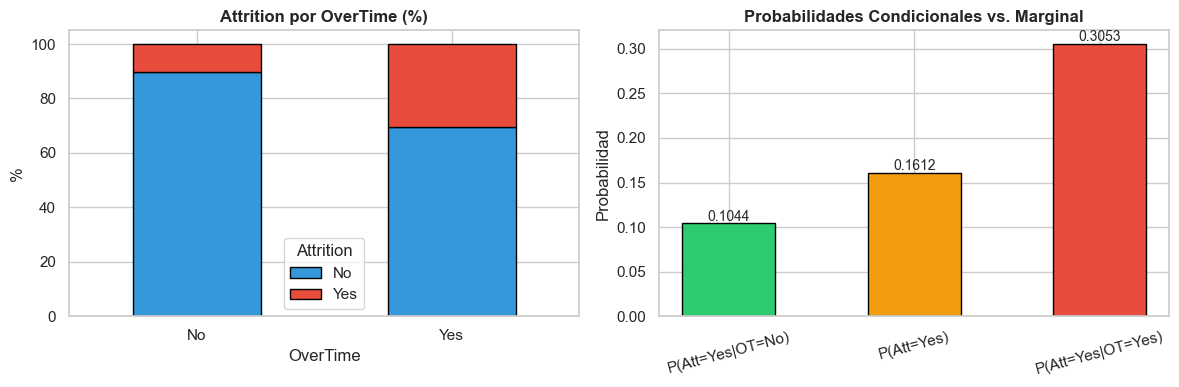

In [108]:
# Visualización Tarea 2
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barras apiladas
tabla_pct = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100
tabla_pct.plot(kind='bar', stacked=True, ax=axes[0],
               color=['#3498db','#e74c3c'], edgecolor='black')
axes[0].set_title("Attrition por OverTime (%)", fontweight='bold')
axes[0].set_xlabel("OverTime"); axes[0].set_ylabel("%")
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Attrition')

# Comparación de condicionales vs marginal
cats = ['P(Att=Yes|OT=No)', 'P(Att=Yes)', 'P(Att=Yes|OT=Yes)']
vals = [p_att_yes_given_ot_no, p_att_yes, p_att_yes_given_ot_yes]
colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = axes[1].bar(cats, vals, color=colors, edgecolor='black', width=0.5)
axes[1].set_title("Probabilidades Condicionales vs. Marginal", fontweight='bold')
axes[1].set_ylabel("Probabilidad")
axes[1].tick_params(axis='x', rotation=15)
for bar, v in zip(bars, vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                 f'{v:.4f}', ha='center', fontsize=10)
plt.tight_layout(); plt.show()


### Tarea 3 — Department vs. Attrition

TABLA: Department vs. Attrition
Attrition                 No  Yes  Total
Department                              
Human Resources           51   12     63
Research & Development   828  133    961
Sales                    354   92    446
Total                   1233  237   1470

PROBABILIDADES CONDICIONALES P(Att=Yes | Dept)
Attrition                   No     Yes
Department                            
Human Resources         0.8095  0.1905
Research & Development  0.8616  0.1384
Sales                   0.7937  0.2063

PROBABILIDADES MARGINALES P(Dept):
Department
Human Resources           0.0429
Research & Development    0.6538
Sales                     0.3034
dtype: float64

Departamento con MAYOR tasa de desercion: 'Sales'
   P(Att=Yes | Sales) = 0.2063
Conviene mirar el tamano del departamento para no confundir tasa con volumen absoluto.
Vamos a observar por departamento la probabilidad de abandono (Att=Yes). Barra horizontal:


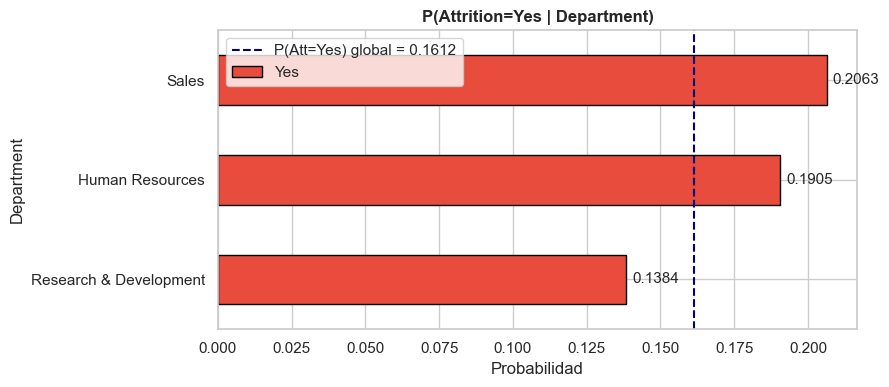

In [109]:
# Tabla de contingencia
tabla_dept = pd.crosstab(df['Department'], df['Attrition'], margins=True, margins_name='Total')
print("TABLA: Department vs. Attrition")
print(tabla_dept)

# Probabilidades condicionales por departamento
print("\nPROBABILIDADES CONDICIONALES P(Att=Yes | Dept)")
cond_dept = pd.crosstab(df['Department'], df['Attrition'], normalize='index').round(4)
print(cond_dept)

# Probabilidades conjuntas
joint_dept = pd.crosstab(df['Department'], df['Attrition'], normalize='all').round(4)
marginal_dept = joint_dept.sum(axis=1)
print("\nPROBABILIDADES MARGINALES P(Dept):")
print(marginal_dept.round(4))

dpto_max = cond_dept['Yes'].idxmax()
print(f"\nDepartamento con MAYOR tasa de desercion: '{dpto_max}'")
print(f"   P(Att=Yes | {dpto_max}) = {cond_dept.loc[dpto_max,'Yes']:.4f}")
print("Conviene mirar el tamano del departamento para no confundir tasa con volumen absoluto.")

print("Vamos a observar por departamento la probabilidad de abandono (Att=Yes). Barra horizontal:")

# Grafico
fig, ax = plt.subplots(figsize=(9, 4))
cond_dept['Yes'].sort_values().plot(kind='barh', ax=ax, color='#e74c3c', edgecolor='black')
ax.axvline(x=p_att_yes, color='navy', linestyle='--', linewidth=1.5,
           label=f'P(Att=Yes) global = {p_att_yes:.4f}')
ax.set_title("P(Attrition=Yes | Department)", fontweight='bold')
ax.set_xlabel("Probabilidad"); ax.legend()
for i, v in enumerate(cond_dept['Yes'].sort_values()):
    ax.text(v+0.002, i, f'{v:.4f}', va='center')
plt.tight_layout(); plt.show()


### Tarea 4 — Probabilidad Total con Department

In [110]:
# Tabla resumen
print("Contexto para la regla de probabilidad total:")
print("A es el evento 'Attrition=Yes' y Bi es la particion por 'Department'.")
print("B es el evento 'Attrition=Yes' sin condicionamiento (marginal).")
print("Bi es la probabilidad marginal de cada departamento.")
print("A|Bi es la probabilidad condicional de A dado Bi.")
print("\nVeamos la tabla resumen:")

resumen = df.groupby('Department').apply(lambda g: pd.Series({
    'n': len(g),
    'P(Bi)': len(g)/N,
    'P(A|Bi)': (g['Attrition']=='Yes').mean(),
})).reset_index()
resumen['P(A|Bi)·P(Bi)'] = resumen['P(Bi)'] * resumen['P(A|Bi)']

print("REGLA DE PROBABILIDAD TOTAL — Particion: Department")
print("=" * 65)
print(resumen[['Department','P(Bi)','P(A|Bi)','P(A|Bi)·P(Bi)']].to_string(index=False, float_format='%.4f'))
print("=" * 65)
p_total = resumen['P(A|Bi)·P(Bi)'].sum()
p_directo = (df['Attrition']=='Yes').sum() / N
print(f"  Suma ΣP(A|Bi)·P(Bi) = {p_total:.6f}")
print(f"  237/1470 directo     = {p_directo:.6f}")
print(f"  Validar si las sumas coinciden: {'Si' if abs(p_total - p_directo) < 1e-6 else 'No'}")
print("Este paso sirve como chequeo de consistencia del calculo.")


Contexto para la regla de probabilidad total:
A es el evento 'Attrition=Yes' y Bi es la particion por 'Department'.
B es el evento 'Attrition=Yes' sin condicionamiento (marginal).
Bi es la probabilidad marginal de cada departamento.
A|Bi es la probabilidad condicional de A dado Bi.

Veamos la tabla resumen:
REGLA DE PROBABILIDAD TOTAL — Particion: Department
            Department  P(Bi)  P(A|Bi)  P(A|Bi)·P(Bi)
       Human Resources 0.0429   0.1905         0.0082
Research & Development 0.6537   0.1384         0.0905
                 Sales 0.3034   0.2063         0.0626
  Suma ΣP(A|Bi)·P(Bi) = 0.161224
  237/1470 directo     = 0.161224
  Validar si las sumas coinciden: Si
Este paso sirve como chequeo de consistencia del calculo.


### Tarea 5 — Probabilidad Total con JobSatisfaction

 Niveles de la variable JobSatisfaction 

1 'Low'
2 'Medium'
3 'High' 
4 'Very High'

REGLA DE PROBABILIDAD TOTAL — Particion: JobSatisfaction
 JobSatisfaction  P(Bi)  P(A|Bi)  P(A|Bi)·P(Bi)
               1 0.1966   0.2284         0.0449
               2 0.1905   0.1643         0.0313
               3 0.3007   0.1652         0.0497
               4 0.3122   0.1133         0.0354
  Suma ΣP(A|Bi)·P(Bi) = 0.161224
  P(Att=Yes) global    = 0.161224
  ¿Coinciden? SI


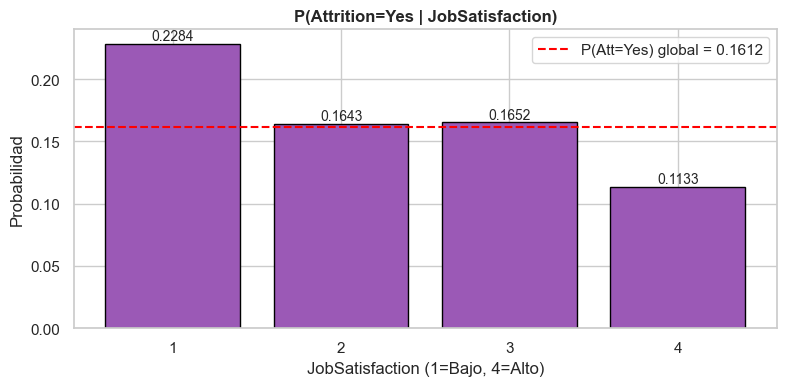

Conclusión principal: a mayor satisfacción (especialmente Very High), menor probabilidad de rotación. El grupo Low tiene el riesgo más alto.
En terminos humanos, niveles bajos de satisfaccion son un foco claro de intervencion.


In [111]:
print(""" Niveles de la variable JobSatisfaction \n
1 'Low'
2 'Medium'
3 'High' 
4 'Very High'
""")
resumen_js = df.groupby('JobSatisfaction').apply(lambda g: pd.Series({
    'n': len(g),
    'P(Bi)': len(g)/N,
    'P(A|Bi)': (g['Attrition']=='Yes').mean(),
})).reset_index()
resumen_js['P(A|Bi)·P(Bi)'] = resumen_js['P(Bi)'] * resumen_js['P(A|Bi)']

print("REGLA DE PROBABILIDAD TOTAL — Particion: JobSatisfaction")
print("=" * 65)
print(resumen_js[['JobSatisfaction','P(Bi)','P(A|Bi)','P(A|Bi)·P(Bi)']].to_string(index=False, float_format='%.4f'))
print("=" * 65)
p_total_js = resumen_js['P(A|Bi)·P(Bi)'].sum()
print(f"  Suma ΣP(A|Bi)·P(Bi) = {p_total_js:.6f}")
print(f"  P(Att=Yes) global    = {p_directo:.6f}")
print(f"  ¿Coinciden? {'SI' if abs(p_total_js - p_directo) < 1e-4 else 'Diferencia minima por redondeo'}")
# Grafico
fig, ax = plt.subplots(figsize=(8,4))
bars = ax.bar(resumen_js['JobSatisfaction'].astype(str),
              resumen_js['P(A|Bi)'], color='#9b59b6', edgecolor='black')
ax.axhline(y=p_directo, color='red', linestyle='--', linewidth=1.5,
           label=f'P(Att=Yes) global = {p_directo:.4f}')
ax.set_title("P(Attrition=Yes | JobSatisfaction)", fontweight='bold')
ax.set_xlabel("JobSatisfaction (1=Bajo, 4=Alto)"); ax.set_ylabel("Probabilidad")
ax.legend()
for bar, v in zip(bars, resumen_js['P(A|Bi)']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f'{v:.4f}', ha='center', fontsize=10)
plt.tight_layout(); plt.show()

print("Conclusión principal: a mayor satisfacción (especialmente Very High), menor probabilidad de rotación. El grupo Low tiene el riesgo más alto.")
print("En terminos humanos, niveles bajos de satisfaccion son un foco claro de intervencion.")


---
## 4. Teorema de Bayes

$$P(B_i|A) = \frac{P(A|B_i)\,P(B_i)}{\sum_j P(A|B_j)\,P(B_j)}$$


### Tarea 6 — ¿De que departamento proviene quien deserto?

TEOREMA DE BAYES — P(Dept | Attrition=Yes)
            Department  P(Bi)  P(A|Bi)  P(A|Bi)·P(Bi)  P(Bi|A)
       Human Resources 0.0429   0.1905         0.0082   0.0506
Research & Development 0.6537   0.1384         0.0905   0.5612
                 Sales 0.3034   0.2063         0.0626   0.3882
  Suma P(Bi|A) = 1.000000

  Mayor probabilidad a POSTERIORI : Research & Development
  Mayor TASA de desercion P(A|Bi): Sales

DIFERENCIA:
  P(A|Bi)  = P(Att=Yes | Dept)  → que tan frecuente es desertar en ese depto.
  P(Bi|A)  = P(Dept | Att=Yes)  → dado que deserto, ¿de que depto viene?
  R&D puede tener la mayor P(Bi|A) por ser el depto mas grande (efecto de tamano).

Verificacion directa (conteo en Att=Yes):
Department
Research & Development    0.5612
Sales                     0.3882
Human Resources           0.0506
Name: proportion, dtype: float64


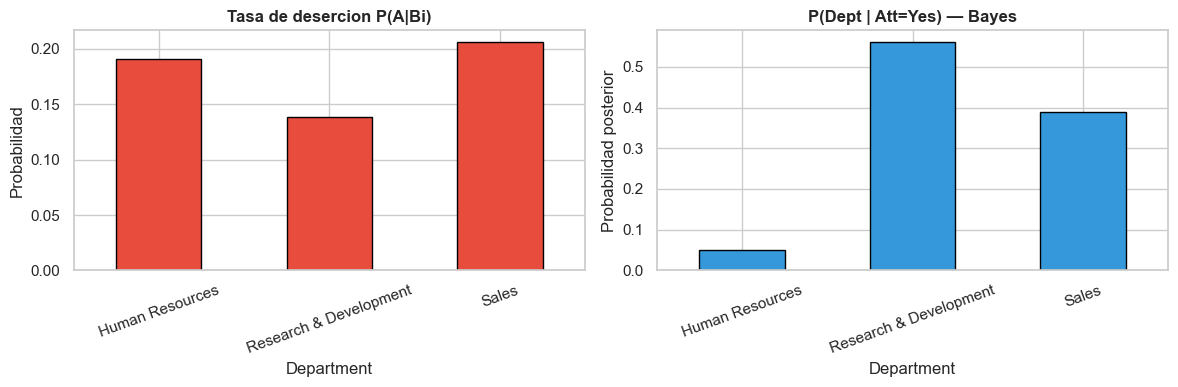

El departamento de R&D tiene la mayor probabilidad posterior debido a su gran tamaño, 
 aunque no es el que tiene la mayor tasa de desercion. Esto ilustra la diferencia entre frecuencia (tasa) y probabilidad posterior en el contexto del teorema de Bayes.
En la practica, el area mas grande puede dominar la probabilidad posterior aunque no tenga la mayor tasa.


In [112]:
resumen['P(Bi|A)'] = resumen['P(A|Bi)·P(Bi)'] / p_total

print("TEOREMA DE BAYES — P(Dept | Attrition=Yes)")
print("=" * 75)
print(resumen[['Department','P(Bi)','P(A|Bi)','P(A|Bi)·P(Bi)','P(Bi|A)']].to_string(
      index=False, float_format='%.4f'))
print("=" * 75)
print(f"  Suma P(Bi|A) = {resumen['P(Bi|A)'].sum():.6f}")

dpto_max_posterior = resumen.loc[resumen['P(Bi|A)'].idxmax(), 'Department']
dpto_max_tasa      = resumen.loc[resumen['P(A|Bi)'].idxmax(), 'Department']
print(f"\n  Mayor probabilidad a POSTERIORI : {dpto_max_posterior}")
print(f"  Mayor TASA de desercion P(A|Bi): {dpto_max_tasa}")
print("\nDIFERENCIA:")
print("  P(A|Bi)  = P(Att=Yes | Dept)  → que tan frecuente es desertar en ese depto.")
print("  P(Bi|A)  = P(Dept | Att=Yes)  → dado que deserto, ¿de que depto viene?")
print("  R&D puede tener la mayor P(Bi|A) por ser el depto mas grande (efecto de tamano).")

# Verificacion directa
verificacion = df[df['Attrition']=='Yes']['Department'].value_counts(normalize=True)
print("\nVerificacion directa (conteo en Att=Yes):")
print(verificacion.round(4))

# Grafico
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
resumen.set_index('Department')[['P(A|Bi)']].plot(kind='bar', ax=axes[0],
    color='#e74c3c', legend=False, edgecolor='black')
axes[0].set_title("Tasa de desercion P(A|Bi)", fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)
axes[0].set_ylabel("Probabilidad")

resumen.set_index('Department')[['P(Bi|A)']].plot(kind='bar', ax=axes[1],
    color='#3498db', legend=False, edgecolor='black')
axes[1].set_title("P(Dept | Att=Yes) — Bayes", fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)
axes[1].set_ylabel("Probabilidad posterior")
plt.tight_layout(); plt.show()

print("El departamento de R&D tiene la mayor probabilidad posterior debido a su gran tamaño, \n aunque no es el que tiene la mayor tasa de desercion. Esto ilustra la diferencia entre frecuencia (tasa) y probabilidad posterior en el contexto del teorema de Bayes.")
print("En la practica, el area mas grande puede dominar la probabilidad posterior aunque no tenga la mayor tasa.")


### Tarea 7 — Bayes: Clasificador de ML

Este es un ejemplo didactico para ilustrar la falacia de la tasa base en el contexto de un modelo de prediccion de desercion.
  Sensibilidad P(Pred=Yes|Att=Yes) = 0.80
  Tasa FP      P(Pred=Yes|Att=No)  = 0.10

  a) Con tasa base = 0.1612:
     VPP = P(Att=Yes | Pred=Yes) = 0.6059  (60.6%)

  b) Interpretacion:
     Si el modelo predice desercion, hay un 60.6% de probabilidad
     de que el empleado efectivamente deserte.

  c) Con tasa base = 50%:
     VPP = 0.8889  (88.9%)

Falacia de la tasa base:
   Al duplicar la prevalencia (16.1%→50%), el VPP sube de
   60.6% a 88.9%.
   El mismo modelo es mas confiable en poblaciones de alto riesgo.


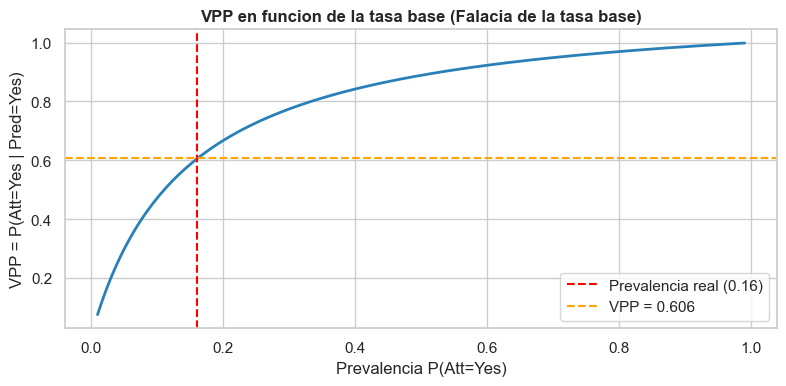

Cambiar la prevalencia cambia el vpp significativamente, lo que ilustra la falacia de la tasa base: un modelo con buena sensibilidad y especificidad puede tener un VPP bajo si la prevalencia del evento es baja.
Esto recuerda que los modelos se deben calibrar al contexto donde se aplican.


In [113]:
# Datos del problema
sensibilidad = 0.80   # P(Predice Yes | Att=Yes)
fpr          = 0.10   # P(Predice Yes | Att=No)
p_pos        = 0.1612 # P(Att=Yes) tasa base

def ppv_bayes(sens, fpr, prevalencia):
    numerador   = sens * prevalencia
    denominador = sens * prevalencia + fpr * (1 - prevalencia)
    return numerador / denominador

ppv_real = ppv_bayes(sensibilidad, fpr, p_pos)
ppv_50   = ppv_bayes(sensibilidad, fpr, 0.50)

print("Este es un ejemplo didactico para ilustrar la falacia de la tasa base en el contexto de un modelo de prediccion de desercion.")
print("=" * 55)
print(f"  Sensibilidad P(Pred=Yes|Att=Yes) = {sensibilidad:.2f}")
print(f"  Tasa FP      P(Pred=Yes|Att=No)  = {fpr:.2f}")
print()
print(f"  a) Con tasa base = {p_pos:.4f}:")
print(f"     VPP = P(Att=Yes | Pred=Yes) = {ppv_real:.4f}  ({ppv_real:.1%})")
print()
print("  b) Interpretacion:")
print(f"     Si el modelo predice desercion, hay un {ppv_real:.1%} de probabilidad")
print("     de que el empleado efectivamente deserte.")
print()
print("  c) Con tasa base = 50%:")
print(f"     VPP = {ppv_50:.4f}  ({ppv_50:.1%})")
print()
print("Falacia de la tasa base:")
print(f"   Al duplicar la prevalencia ({p_pos:.1%}→50%), el VPP sube de")
print(f"   {ppv_real:.1%} a {ppv_50:.1%}.")
print("   El mismo modelo es mas confiable en poblaciones de alto riesgo.")

# Grafico: VPP vs tasa base
tasas = np.linspace(0.01, 0.99, 200)
ppvs  = [ppv_bayes(sensibilidad, fpr, t) for t in tasas]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tasas, ppvs, color='#2980b9', linewidth=2)
ax.axvline(x=p_pos, color='red', linestyle='--', label=f'Prevalencia real ({p_pos:.2f})')
ax.axhline(y=ppv_real, color='orange', linestyle='--', label=f'VPP = {ppv_real:.3f}')
ax.set_title("VPP en funcion de la tasa base (Falacia de la tasa base)", fontweight='bold')
ax.set_xlabel("Prevalencia P(Att=Yes)"); ax.set_ylabel("VPP = P(Att=Yes | Pred=Yes)")
ax.legend(); plt.tight_layout(); plt.show()

print("Cambiar la prevalencia cambia el vpp significativamente, lo que ilustra la falacia de la tasa base: un modelo con buena sensibilidad y especificidad puede tener un VPP bajo si la prevalencia del evento es baja.")
print("Esto recuerda que los modelos se deben calibrar al contexto donde se aplican.")


---
## 5. Teorema del Límite Central (TLC)

$$\bar{X}_n \xrightarrow{d} N\!\left(\mu,\,\frac{\sigma^2}{n}\right) \quad \Leftrightarrow \quad Z_n = \frac{\bar{X}_n - \mu}{\sigma/\sqrt{n}} \xrightarrow{d} N(0,1)$$


### Tarea 8 — Verificacion Empirica del TLC con MonthlyIncome

Parámetros de MonthlyIncome:
  µ (media)           = $6,502.93
  σ (desv. estándar)  = $4,707.96
  Asimetría (skewness)= 1.370  → distribución sesgada a la derecha


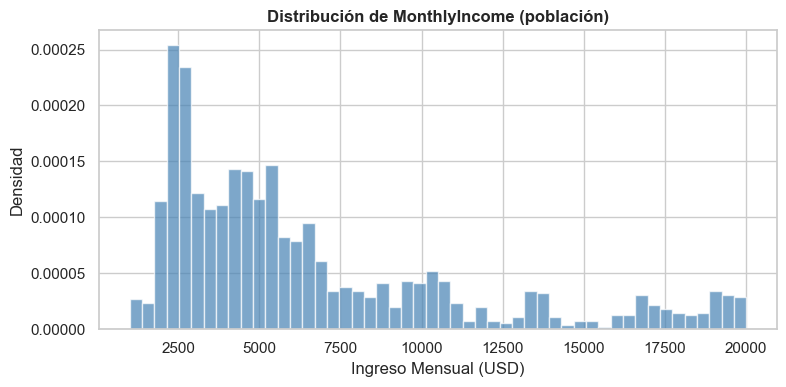

In [114]:
income = df['MonthlyIncome'].values
mu    = income.mean()
sigma = income.std(ddof=1)

print(f"Parámetros de MonthlyIncome:")
print(f"  µ (media)           = ${mu:,.2f}")
print(f"  σ (desv. estándar)  = ${sigma:,.2f}")
print(f"  Asimetría (skewness)= {pd.Series(income).skew():.3f}  → distribución sesgada a la derecha")

# Histograma de la distribución original
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(income, bins=50, density=True, color='steelblue', alpha=0.7, edgecolor='white')
ax.set_title("Distribución de MonthlyIncome (población)", fontweight='bold')
ax.set_xlabel("Ingreso Mensual (USD)"); ax.set_ylabel("Densidad")
plt.tight_layout(); plt.show()


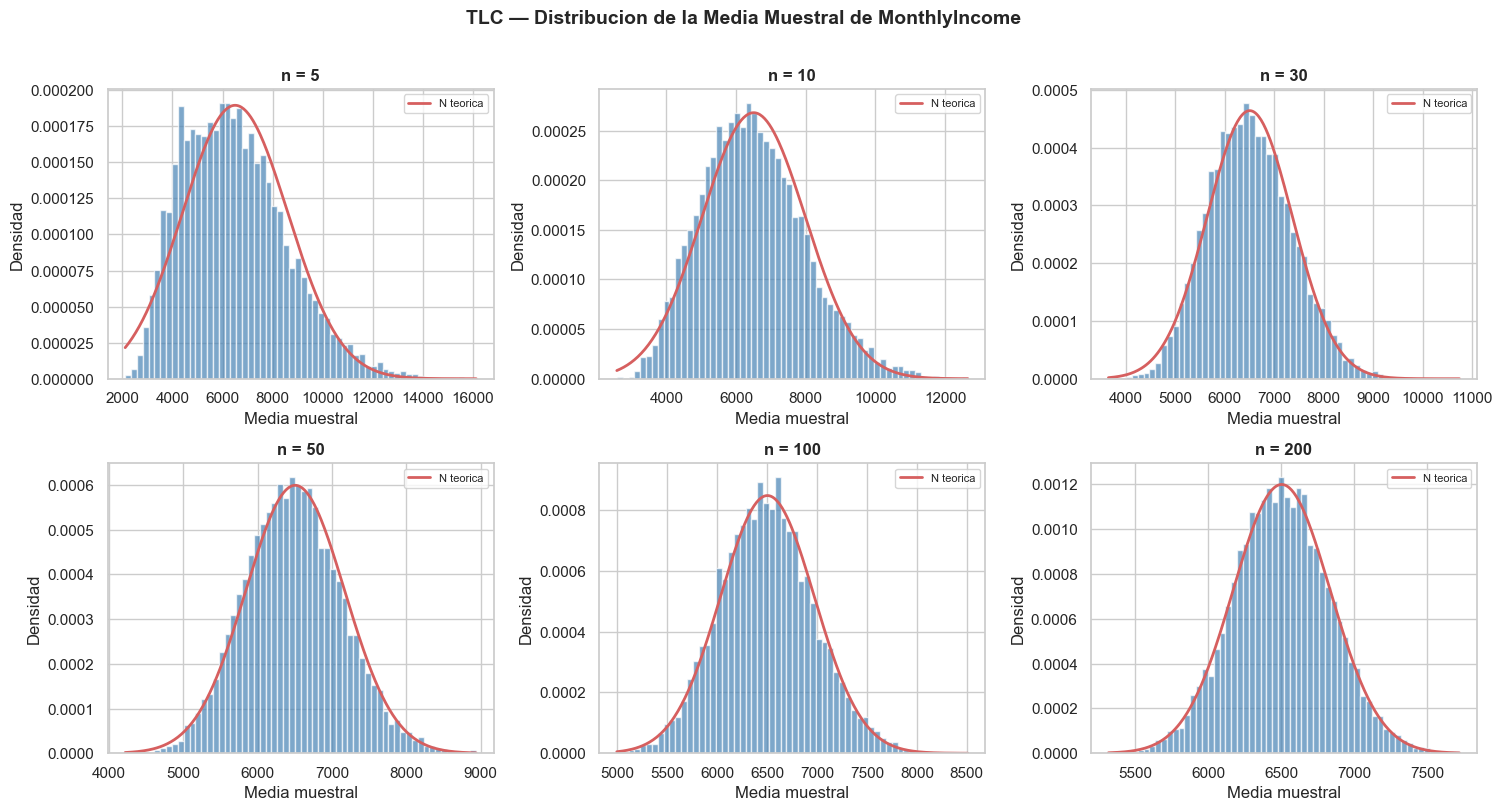


TABLA COMPARATIVA TLC
  n  σ/√n (teórico)  SE observado
  5         2105.46       2081.41
 10         1488.79       1498.39
 30          859.55        856.22
 50          665.81        658.24
100          470.80        474.36
200          332.90        333.49

La distribucion de X̄ luce razonablemente normal a partir de n ≈ 30.


In [115]:
# Simulacion TLC
np.random.seed(123)
ns = [5, 10, 30, 50, 100, 200]
B  = 10_000

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
tabla_tlc = []

for idx, n in enumerate(ns):
    medias = np.array([np.mean(np.random.choice(income, n, replace=True)) for _ in range(B)])
    se_teorico = sigma / np.sqrt(n)
    se_obs     = medias.std(ddof=1)
    tabla_tlc.append({'n': n, 'σ/√n (teórico)': round(se_teorico,2), 'SE observado': round(se_obs,2)})

    ax = axes[idx]
    ax.hist(medias, bins=60, density=True, color='steelblue', alpha=0.7, edgecolor='white')
    x = np.linspace(medias.min(), medias.max(), 300)
    ax.plot(x, norm.pdf(x, mu, se_teorico), 'r-', linewidth=2, label='N teorica')
    ax.set_title(f'n = {n}', fontweight='bold')
    ax.set_xlabel("Media muestral"); ax.set_ylabel("Densidad")
    ax.legend(fontsize=8)

plt.suptitle("TLC — Distribucion de la Media Muestral de MonthlyIncome", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

# Tabla comparativa
df_tlc = pd.DataFrame(tabla_tlc)
print("\nTABLA COMPARATIVA TLC")
print(df_tlc.to_string(index=False))
print("\nLa distribucion de X̄ luce razonablemente normal a partir de n ≈ 30.")


### Tarea 9 — TLC: Aplicaciones Numericas

Comparacion de asimetria:
  MonthlyIncome    — skewness = 1.370
  DistanceFromHome — skewness = 0.958


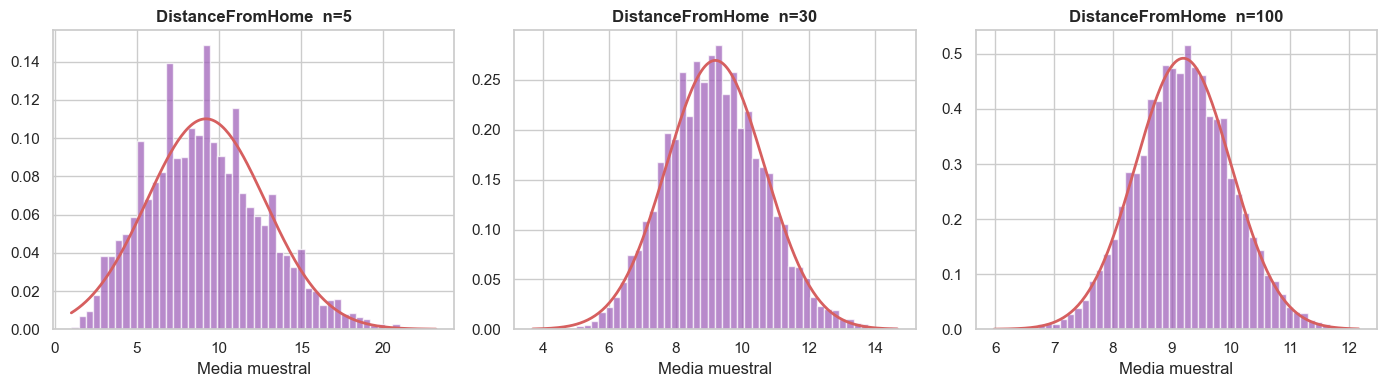

DistanceFromHome tiene mayor asimetria; en la practica suele requerir n mas grande para que la media se aproxime bien a una normal.

b) P(6000 ≤ X̄ ≤ 7000) con n=50:
   µ = 6502.93,  SE = σ/√50 = 665.81
   P = Φ(z2) - Φ(z1) = 0.5473  (54.73%)


In [116]:
# a) TLC con DistanceFromHome
dist_home = df['DistanceFromHome'].values
mu_d  = dist_home.mean()
sig_d = dist_home.std(ddof=1)

print("Comparacion de asimetria:")
print(f"  MonthlyIncome    — skewness = {pd.Series(income).skew():.3f}")
print(f"  DistanceFromHome — skewness = {pd.Series(dist_home).skew():.3f}")

ns_test = [5, 30, 100]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, n in enumerate(ns_test):
    medias = np.array([np.mean(np.random.choice(dist_home, n, replace=True)) for _ in range(10000)])
    se_t = sig_d / np.sqrt(n)
    axes[i].hist(medias, bins=50, density=True, color='#9b59b6', alpha=0.7, edgecolor='white')
    x = np.linspace(medias.min(), medias.max(), 200)
    axes[i].plot(x, norm.pdf(x, mu_d, se_t), 'r-', linewidth=2)
    axes[i].set_title(f'DistanceFromHome  n={n}', fontweight='bold')
    axes[i].set_xlabel("Media muestral")
plt.tight_layout(); plt.show()

print("DistanceFromHome tiene mayor asimetria; en la practica suele requerir n mas grande para que la media se aproxime bien a una normal.")

# b) P(6000 ≤ X̄ ≤ 7000) con n=50
n_test = 50
se_50 = sigma / np.sqrt(n_test)
prob = norm.cdf(7000, mu, se_50) - norm.cdf(6000, mu, se_50)
print(f"\nb) P(6000 ≤ X̄ ≤ 7000) con n=50:")
print(f"   µ = {mu:.2f},  SE = σ/√50 = {se_50:.2f}")
print(f"   P = Φ(z2) - Φ(z1) = {prob:.4f}  ({prob:.2%})")


---
## 6. Estimación Puntual de Parámetros


### Tarea 10 — Estimaciones Puntuales

In [117]:
from scipy.stats import median_abs_deviation

media_inc   = df['MonthlyIncome'].mean()
std_inc     = df['MonthlyIncome'].std(ddof=1)
mediana_inc = df['MonthlyIncome'].median()
p_hat       = (df['Attrition']=='Yes').mean()
n_total     = len(df)

mu_no  = df.loc[df['Attrition']=='No',  'MonthlyIncome'].mean()
mu_yes = df.loc[df['Attrition']=='Yes', 'MonthlyIncome'].mean()

print("ESTIMACIONES PUNTUALES")
print("=" * 60)
print(f"{'Parámetro':<35} {'Estimador':<6} {'Valor':>12}")
print("-" * 60)
print(f"{'Media MonthlyIncome (µ)':<35} {'X̄':<6} ${media_inc:>11,.2f}")
print(f"{'Desv. estándar (σ)':<35} {'S':<6} ${std_inc:>11,.2f}")
print(f"{'Mediana MonthlyIncome':<35} {'X̃':<6} ${mediana_inc:>11,.2f}")
print(f"{'Proporción deserción (p)':<35} {'p̂':<6} {p_hat:>12.4f}")
print(f"{'µNo − µYes (ingreso)':<35} {'X̄₁−X̄₂':<6} ${mu_no-mu_yes:>11,.2f}")

# b) Media vs Mediana
print("\nb) Media vs. Mediana de MonthlyIncome:")
print(f"   Media   = ${media_inc:,.2f}")
print(f"   Mediana = ${mediana_inc:,.2f}")
print(f"   La media > mediana confirma sesgo a la derecha (pocos empleados con ingresos muy altos).")
print(f"   La mediana es más robusta ante valores extremos.")

# c) Error estándar de p̂
se_phat = np.sqrt(p_hat * (1 - p_hat) / n_total)
print(f"\nc) Error estándar de p̂:  SE = √(p̂(1-p̂)/n) = {se_phat:.4f}")
print(f"   Interpretación: la estimación p̂={p_hat:.4f} tiene una variabilidad de ±{se_phat:.4f}.")
print("   En lenguaje simple, p-hat no es exacto y este SE da idea del margen de variacion.")

# d) Estadísticas por departamento
print("\nd) Media y Varianza de YearsAtCompany por Departamento:")
stats_dept = df.groupby('Department')['YearsAtCompany'].agg(
    Media='mean', Varianza='var', Mediana='median', n='count'
).round(3)
print(stats_dept)


ESTIMACIONES PUNTUALES
Parámetro                           Estimador        Valor
------------------------------------------------------------
Media MonthlyIncome (µ)             X̄     $   6,502.93
Desv. estándar (σ)                  S      $   4,707.96
Mediana MonthlyIncome               X̃     $   4,919.00
Proporción deserción (p)            p̂           0.1612
µNo − µYes (ingreso)                X̄₁−X̄₂ $   2,045.65

b) Media vs. Mediana de MonthlyIncome:
   Media   = $6,502.93
   Mediana = $4,919.00
   La media > mediana confirma sesgo a la derecha (pocos empleados con ingresos muy altos).
   La mediana es más robusta ante valores extremos.

c) Error estándar de p̂:  SE = √(p̂(1-p̂)/n) = 0.0096
   Interpretación: la estimación p̂=0.1612 tiene una variabilidad de ±0.0096.
   En lenguaje simple, p-hat no es exacto y este SE da idea del margen de variacion.

d) Media y Varianza de YearsAtCompany por Departamento:
                        Media  Varianza  Mediana    n
Department       

---
## 7. Intervalos de Confianza

| Para | Fórmula |
|------|---------|
| Media µ | $\bar{X} \pm z_{\alpha/2}\, S/\sqrt{n}$ |
| Proporción p | $\hat{p} \pm z_{\alpha/2}\sqrt{\hat{p}(1-\hat{p})/n}$ |
| Diferencia medias | $(\bar{X}_1-\bar{X}_2) \pm t_{\alpha/2,\nu}\sqrt{S_1^2/n_1+S_2^2/n_2}$ |


### Tarea 11 — IC para la Media del Ingreso

In [118]:
# a) A mano
X_bar = df['MonthlyIncome'].mean()
S     = df['MonthlyIncome'].std(ddof=1)
n     = len(df)
SE    = S / np.sqrt(n)
z025  = 1.96

IC95_manual = (X_bar - z025*SE, X_bar + z025*SE)

print("IC AL 95% PARA µ (MonthlyIncome) — Cálculo Manual")
print("=" * 55)
print(f"  X̄  = ${X_bar:,.4f}")
print(f"  S   = ${S:,.4f}")
print(f"  n   = {n}")
print(f"  SE  = S/√n = ${SE:,.4f}")
print(f"  z₀.₀₂₅ = {z025}")
print(f"  IC 95% = [{IC95_manual[0]:,.2f} , {IC95_manual[1]:,.2f}]")

# b) Con scipy (t de Student exacta)
from scipy.stats import t as t_dist
ic95_scipy = t_dist.interval(0.95, df=n-1, loc=X_bar, scale=SE)
print(f"\n  IC 95% (t exacta, scipy) = [{ic95_scipy[0]:,.2f} , {ic95_scipy[1]:,.2f}]")

# c) 90% y 99%
ic90 = t_dist.interval(0.90, df=n-1, loc=X_bar, scale=SE)
ic99 = t_dist.interval(0.99, df=n-1, loc=X_bar, scale=SE)
print(f"\n  IC 90% = [{ic90[0]:,.2f} , {ic90[1]:,.2f}]  Amplitud = {ic90[1]-ic90[0]:,.2f}")
print(f"  IC 95% = [{ic95_scipy[0]:,.2f} , {ic95_scipy[1]:,.2f}]  Amplitud = {ic95_scipy[1]-ic95_scipy[0]:,.2f}")
print(f"  IC 99% = [{ic99[0]:,.2f} , {ic99[1]:,.2f}]  Amplitud = {ic99[1]-ic99[0]:,.2f}")
print("  Mayor nivel de confianza → IC más amplio.")

# d) Interpretación
print(f"\nd) INTERPRETACIÓN:")
print(f"  Si tomáramos 100 muestras del mismo tamaño, aproximadamente 95 de ellas")
print(f"  producirían intervalos que contendrían el verdadero µ de MonthlyIncome.")
print(f"  Estamos al 95% seguros de que µ ∈ [${ic95_scipy[0]:,.2f}, ${ic95_scipy[1]:,.2f}].")
print("  Para decisiones internas, el intervalo es mas informativo que un solo promedio.")


IC AL 95% PARA µ (MonthlyIncome) — Cálculo Manual
  X̄  = $6,502.9313
  S   = $4,707.9568
  n   = 1470
  SE  = S/√n = $122.7931
  z₀.₀₂₅ = 1.96
  IC 95% = [6,262.26 , 6,743.61]

  IC 95% (t exacta, scipy) = [6,262.06 , 6,743.80]

  IC 90% = [6,300.83 , 6,705.04]  Amplitud = 404.21
  IC 95% = [6,262.06 , 6,743.80]  Amplitud = 481.74
  IC 99% = [6,186.23 , 6,819.64]  Amplitud = 633.41
  Mayor nivel de confianza → IC más amplio.

d) INTERPRETACIÓN:
  Si tomáramos 100 muestras del mismo tamaño, aproximadamente 95 de ellas
  producirían intervalos que contendrían el verdadero µ de MonthlyIncome.
  Estamos al 95% seguros de que µ ∈ [$6,262.06, $6,743.80].
  Para decisiones internas, el intervalo es mas informativo que un solo promedio.


### Tarea 12 — IC para Proporcion y Diferencia de Medias

In [119]:
from statsmodels.stats.proportion import proportion_confint

# a) IC 95% para p(Att=Yes)
n_yes_total = (df['Attrition']=='Yes').sum()
p_hat_att   = n_yes_total / n

# Manual
z_025 = 1.96
se_p  = np.sqrt(p_hat_att * (1 - p_hat_att) / n)
ic_p_manual = (p_hat_att - z_025*se_p, p_hat_att + z_025*se_p)

# statsmodels (Wilson)
ic_p_wilson = proportion_confint(n_yes_total, n, alpha=0.05, method='wilson')

print("IC 95% PARA PROPORCIÓN p(Attrition=Yes)")
print(f"  p̂ = {p_hat_att:.4f}")
print(f"  IC normal  = [{ic_p_manual[0]:.4f}, {ic_p_manual[1]:.4f}]")
print(f"  IC Wilson  = [{ic_p_wilson[0]:.4f}, {ic_p_wilson[1]:.4f}]")
print(f"  Interpretación: con 95% de confianza, entre el {ic_p_wilson[0]:.1%} y el {ic_p_wilson[1]:.1%}")
print(f"  de los empleados desertarán.")

# b) ICs por departamento
print("\nIC 95% por Departamento:")
for dept_name in df['Department'].unique():
    sub = df[df['Department']==dept_name]
    k = (sub['Attrition']=='Yes').sum()
    ni = len(sub)
    low, high = proportion_confint(k, ni, alpha=0.05, method='wilson')
    print(f"  {dept_name:<35}: [{low:.4f}, {high:.4f}]  (n={ni})")
print("  Si los intervalos se traslapan, no hay diferencia significativa entre departamentos.")
print("  Como regla practica, buscamos diferencias claras y no solo cambios minimos.")

# c) IC para µNo − µYes (Welch)
inc_no  = df.loc[df['Attrition']=='No',  'MonthlyIncome'].values
inc_yes = df.loc[df['Attrition']=='Yes', 'MonthlyIncome'].values
result_welch = ttest_ind(inc_no, inc_yes, equal_var=False)

# IC manual Welch
diff_means = inc_no.mean() - inc_yes.mean()
se_diff = np.sqrt(inc_no.var(ddof=1)/len(inc_no) + inc_yes.var(ddof=1)/len(inc_yes))
df_welch = (inc_no.var(ddof=1)/len(inc_no) + inc_yes.var(ddof=1)/len(inc_yes))**2 /            ((inc_no.var(ddof=1)/len(inc_no))**2/(len(inc_no)-1) + (inc_yes.var(ddof=1)/len(inc_yes))**2/(len(inc_yes)-1))
t_crit = t_dist.ppf(0.975, df=df_welch)
ic_diff = (diff_means - t_crit*se_diff, diff_means + t_crit*se_diff)

print(f"\nIC 95% para µNo − µYes (Welch):")
print(f"  Diferencia = ${diff_means:,.2f}")
print(f"  IC = [${ic_diff[0]:,.2f}, ${ic_diff[1]:,.2f}]")
print(f"  ¿Contiene el cero? {'SÍ' if ic_diff[0]<=0<=ic_diff[1] else 'NO → diferencia significativa'}")
print(f"  Quienes NO desertan ganan en promedio ${diff_means:,.2f} más que quienes sí desertan.")

# d) Submuestra n=100
np.random.seed(99)
sub100 = df['MonthlyIncome'].sample(100)
ic100 = t_dist.interval(0.95, df=99, loc=sub100.mean(), scale=sub100.std(ddof=1)/np.sqrt(100))
print(f"\nd) IC 95% con submuestra n=100:")
print(f"  [{ic100[0]:,.2f}, {ic100[1]:,.2f}]  Amplitud = {ic100[1]-ic100[0]:,.2f}")
print(f"  IC original (n=1470): Amplitud = {ic95_scipy[1]-ic95_scipy[0]:,.2f}")
print(f"  Menor n → IC más amplio (más incertidumbre).")


IC 95% PARA PROPORCIÓN p(Attrition=Yes)
  p̂ = 0.1612
  IC normal  = [0.1424, 0.1800]
  IC Wilson  = [0.1433, 0.1809]
  Interpretación: con 95% de confianza, entre el 14.3% y el 18.1%
  de los empleados desertarán.

IC 95% por Departamento:
  Sales                              : [0.1713, 0.2463]  (n=446)
  Research & Development             : [0.1180, 0.1617]  (n=961)
  Human Resources                    : [0.1125, 0.3041]  (n=63)
  Si los intervalos se traslapan, no hay diferencia significativa entre departamentos.
  Como regla practica, buscamos diferencias claras y no solo cambios minimos.

IC 95% para µNo − µYes (Welch):
  Diferencia = $2,045.65
  IC = [$1,508.24, $2,583.05]
  ¿Contiene el cero? NO → diferencia significativa
  Quienes NO desertan ganan en promedio $2,045.65 más que quienes sí desertan.

d) IC 95% con submuestra n=100:
  [4,595.95, 6,090.29]  Amplitud = 1,494.33
  IC original (n=1470): Amplitud = 481.74
  Menor n → IC más amplio (más incertidumbre).


---
## 8. Pruebas de Hipótesis

> Se rechaza $H_0$ si **valor-p < α**


### Tarea 13 — Prueba t: ¿El ingreso de quienes desertan es menor?

PRUEBA t DE WELCH (unilateral)
H₀: µNo = µYes  vs  H₁: µNo > µYes
  Estadistico t = 7.4826
  Valor-p        = 0.000000
  α              = 0.05

  RECHAZAMOS H₀
  Conclusión: El ingreso de quienes NO desertan es significativamente
  mayor que el de quienes SÍ desertan (p < 0.001).
  En terminos humanos, se observa una brecha real de ingresos que no parece aleatoria.
  Consistente con IC de Tarea 12c que no contiene el cero.


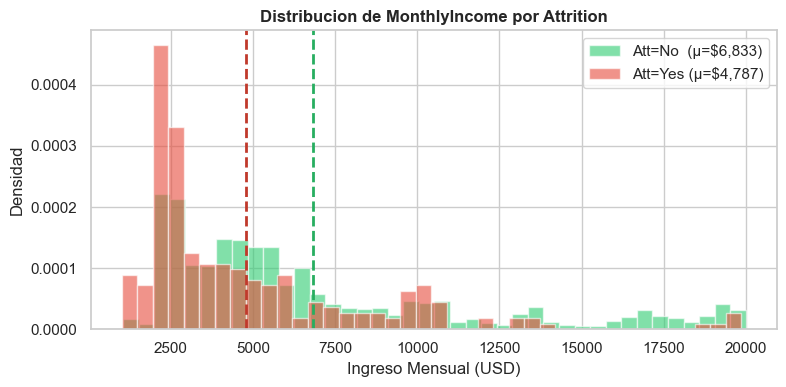

In [120]:
# H0: µYes = µNo   vs   H1: µNo > µYes  (unilateral)
inc_no_  = df.loc[df['Attrition']=='No',  'MonthlyIncome']
inc_yes_ = df.loc[df['Attrition']=='Yes', 'MonthlyIncome']

result_t = ttest_ind(inc_no_, inc_yes_, equal_var=False, alternative='greater')

print("PRUEBA t DE WELCH (unilateral)")
print("H₀: µNo = µYes  vs  H₁: µNo > µYes")
print("=" * 50)
print(f"  Estadistico t = {result_t.statistic:.4f}")
print(f"  Valor-p        = {result_t.pvalue:.6f}")
print(f"  α              = 0.05")
print(f"\n  {'RECHAZAMOS H₀' if result_t.pvalue < 0.05 else 'No rechazamos H₀'}")
print(f"  Conclusión: El ingreso de quienes NO desertan es significativamente")
print(f"  mayor que el de quienes SÍ desertan (p < 0.001).")
print("  En terminos humanos, se observa una brecha real de ingresos que no parece aleatoria.")
print(f"  Consistente con IC de Tarea 12c que no contiene el cero.")

# Visualización
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(inc_no_,  bins=40, alpha=0.6, density=True, color='#2ecc71', label=f'Att=No  (µ=${inc_no_.mean():,.0f})')
ax.hist(inc_yes_, bins=40, alpha=0.6, density=True, color='#e74c3c', label=f'Att=Yes (µ=${inc_yes_.mean():,.0f})')
ax.axvline(inc_no_.mean(),  color='#27ae60', linestyle='--', linewidth=2)
ax.axvline(inc_yes_.mean(), color='#c0392b', linestyle='--', linewidth=2)
ax.set_title("Distribucion de MonthlyIncome por Attrition", fontweight='bold')
ax.set_xlabel("Ingreso Mensual (USD)"); ax.set_ylabel("Densidad"); ax.legend()
plt.tight_layout(); plt.show()


### Tarea 14 — Prueba χ² de Independencia

In [121]:
# H0: Attrition y OverTime son independientes
tabla_chi2 = pd.crosstab(df['OverTime'], df['Attrition'])
chi2_ot, pval_ot, dof_ot, expected_ot = chi2_contingency(tabla_chi2)

print("PRUEBA χ² — Attrition vs OverTime")
print("H₀: independencia  vs  H₁: asociacion")
print("=" * 50)
print(f"  χ² = {chi2_ot:.4f}")
print(f"  gl = {dof_ot}")
print(f"  valor-p = {pval_ot:.6f}")
print(f"  {'RECHAZAMOS H₀: hay asociacion significativa' if pval_ot<0.05 else 'No rechazamos H₀'}")
print("  En la practica, esto sugiere que las horas extra estan ligadas a la rotacion.")

# Dept vs Attrition
tabla_dept_chi2 = pd.crosstab(df['Department'], df['Attrition'])
chi2_d, pval_d, dof_d, _ = chi2_contingency(tabla_dept_chi2)
print(f"\nPRUEBA χ² — Attrition vs Department")
print(f"  χ² = {chi2_d:.4f},  gl = {dof_d},  valor-p = {pval_d:.4f}")
print(f"  {'RECHAZAMOS H₀: hay asociacion' if pval_d<0.05 else 'No rechazamos H₀'}")


PRUEBA χ² — Attrition vs OverTime
H₀: independencia  vs  H₁: asociacion
  χ² = 87.5643
  gl = 1
  valor-p = 0.000000
  RECHAZAMOS H₀: hay asociacion significativa
  En la practica, esto sugiere que las horas extra estan ligadas a la rotacion.

PRUEBA χ² — Attrition vs Department
  χ² = 10.7960,  gl = 2,  valor-p = 0.0045
  RECHAZAMOS H₀: hay asociacion


### Tarea 15 — Prueba Z para Proporcion y Edad

In [122]:
# H0: p = 0.15  vs  H1: p > 0.15
p0    = 0.15
p_hat_z = (df['Attrition']=='Yes').mean()
n_z   = len(df)
Z_stat = (p_hat_z - p0) / np.sqrt(p0*(1-p0)/n_z)
p_val_z = 1 - norm.cdf(Z_stat)

print("PRUEBA Z PARA PROPORCION")
print("H₀: p = 0.15  vs  H₁: p > 0.15")
print("=" * 50)
print(f"  p̂ = {p_hat_z:.4f}")
print(f"  Z = (p̂ − p₀) / √(p₀(1−p₀)/n) = {Z_stat:.4f}")
print(f"  valor-p = {p_val_z:.4f}")
print(f"  α = 0.05")
print(f"  {'RECHAZAMOS H₀' if p_val_z<0.05 else 'No rechazamos H₀'}")

# b) Prueba bilateral edad: ¿difiere la edad entre Att=Yes y Att=No?
age_no  = df.loc[df['Attrition']=='No',  'Age']
age_yes = df.loc[df['Attrition']=='Yes', 'Age']
t_age, p_age = ttest_ind(age_no, age_yes, equal_var=False, alternative='two-sided')
print(f"\nb) Prueba t bilateral — Edad por Attrition:")
print(f"   Media Att=No:  {age_no.mean():.2f} años")
print(f"   Media Att=Yes: {age_yes.mean():.2f} años")
print(f"   t = {t_age:.4f},  p-valor = {p_age:.4f}")
print(f"   {'Diferencia significativa' if p_age<0.05 else 'No significativa'}")

# c) Significancia estadistica vs. practica
diff_edad = abs(age_no.mean() - age_yes.mean())
print(f"\nc) SIGNIFICANCIA ESTADISTICA vs. PRACTICA:")
print(f"   Diferencia de edad = {diff_edad:.2f} años → estadisticamente significativa,")
print(f"   pero ¿es practicamente relevante? Con n=1470, diferencias minimas")
print(f"   resultan significativas. Siempre evaluar el tamaño del efecto (Cohen's d).")
d_cohen = diff_edad / np.sqrt((age_no.std()**2 + age_yes.std()**2)/2)
print(f"   Cohen's d = {d_cohen:.3f} → {'pequeño' if d_cohen<0.5 else 'mediano' if d_cohen<0.8 else 'grande'} efecto.")
print("   En decisiones reales, el tamaño del efecto pesa tanto como el p-valor.")


PRUEBA Z PARA PROPORCION
H₀: p = 0.15  vs  H₁: p > 0.15
  p̂ = 0.1612
  Z = (p̂ − p₀) / √(p₀(1−p₀)/n) = 1.2052
  valor-p = 0.1141
  α = 0.05
  No rechazamos H₀

b) Prueba t bilateral — Edad por Attrition:
   Media Att=No:  37.56 años
   Media Att=Yes: 33.61 años
   t = 5.8280,  p-valor = 0.0000
   Diferencia significativa

c) SIGNIFICANCIA ESTADISTICA vs. PRACTICA:
   Diferencia de edad = 3.95 años → estadisticamente significativa,
   pero ¿es practicamente relevante? Con n=1470, diferencias minimas
   resultan significativas. Siempre evaluar el tamaño del efecto (Cohen's d).
   Cohen's d = 0.425 → pequeño efecto.
   En decisiones reales, el tamaño del efecto pesa tanto como el p-valor.


---
## 9. Estimación Bootstrap

1. Extraer $B$ muestras con reemplazo de tamaño $n$  
2. Calcular $\hat{\theta}^*_b$ en cada remuestra  
3. Usar $\{\hat{\theta}^*_1, \ldots, \hat{\theta}^*_B\}$ para estimar $SE$, sesgo e IC

$$SE_{boot} = \sqrt{\frac{1}{B-1}\sum_{b=1}^B(\hat{\theta}^*_b - \bar{\hat{\theta}}^*)^2}$$


### Tarea 16 — Bootstrap para la Mediana del Ingreso

BOOTSTRAP — Mediana de MonthlyIncome (B=10,000)
  Mediana muestral           = $4,919.00
  Media bootstrap (θ̄*)       = $4,927.32
  Error estandar bootstrap   = $104.08
  Sesgo bootstrap            = $8.32
  IC 95% percentil           = [$4,737.50, $5,150.50]

  |Sesgo| / SE = 0.080  →  pequeño (< 0.25)
  El estimador se ve estable; el sesgo es pequeño respecto al SE.


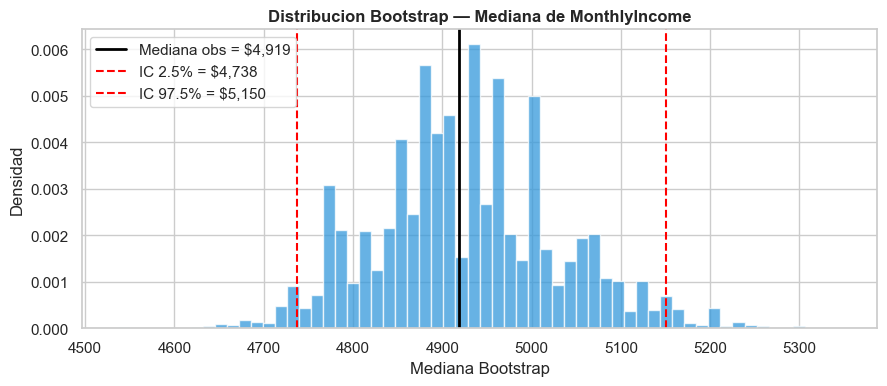

In [123]:
np.random.seed(42)
B = 10_000
income_arr = df['MonthlyIncome'].values
mediana_obs = np.median(income_arr)

# Bootstrap
boot_medianas = np.array([np.median(np.random.choice(income_arr, len(income_arr), replace=True))
                           for _ in range(B)])

se_boot    = boot_medianas.std(ddof=1)
sesgo_boot = boot_medianas.mean() - mediana_obs
ic_boot    = np.percentile(boot_medianas, [2.5, 97.5])

print("BOOTSTRAP — Mediana de MonthlyIncome (B=10,000)")
print("=" * 55)
print(f"  Mediana muestral           = ${mediana_obs:,.2f}")
print(f"  Media bootstrap (θ̄*)       = ${boot_medianas.mean():,.2f}")
print(f"  Error estandar bootstrap   = ${se_boot:,.2f}")
print(f"  Sesgo bootstrap            = ${sesgo_boot:,.2f}")
print(f"  IC 95% percentil           = [${ic_boot[0]:,.2f}, ${ic_boot[1]:,.2f}]")
print(f"\n  |Sesgo| / SE = {abs(sesgo_boot)/se_boot:.3f}  →  {'pequeño (< 0.25)' if abs(sesgo_boot)/se_boot<0.25 else 'moderado'}")
print("  El estimador se ve estable; el sesgo es pequeño respecto al SE.")

# Grafico
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(boot_medianas, bins=60, density=True, color='#3498db', alpha=0.75, edgecolor='white')
ax.axvline(mediana_obs, color='black', linewidth=2, label=f'Mediana obs = ${mediana_obs:,.0f}')
ax.axvline(ic_boot[0],  color='red', linestyle='--', linewidth=1.5, label=f'IC 2.5% = ${ic_boot[0]:,.0f}')
ax.axvline(ic_boot[1],  color='red', linestyle='--', linewidth=1.5, label=f'IC 97.5% = ${ic_boot[1]:,.0f}')
ax.set_title("Distribucion Bootstrap — Mediana de MonthlyIncome", fontweight='bold')
ax.set_xlabel("Mediana Bootstrap"); ax.set_ylabel("Densidad"); ax.legend()
plt.tight_layout(); plt.show()


### Tarea 17 — Bootstrap para Diferencia de Proporciones (OverTime)

BOOTSTRAP — Diferencia de proporciones p(Att=Yes): OT=Yes vs OT=No
  Diferencia observada = 0.2009
  IC 95% percentil     = [0.1528, 0.2489]
  ¿Contiene el cero?   NO → diferencia significativa
  En promedio, OverTime se asocia con una mayor probabilidad de desercion de ~20.1%.


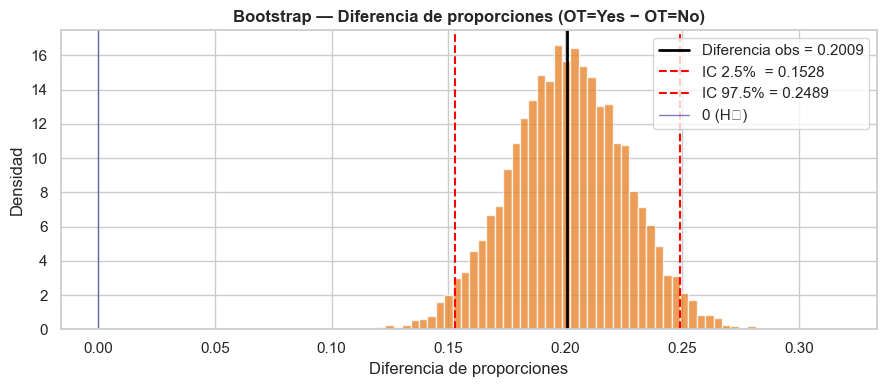

In [124]:
np.random.seed(42)
B = 10_000

ot_yes = df.loc[df['OverTime']=='Yes', 'Attrition'].values
ot_no  = df.loc[df['OverTime']=='No',  'Attrition'].values
obs_diff = (ot_yes=='Yes').mean() - (ot_no=='Yes').mean()

boot_diffs = np.array([
    (np.random.choice(ot_yes, len(ot_yes), replace=True) == 'Yes').mean() -
    (np.random.choice(ot_no,  len(ot_no),  replace=True) == 'Yes').mean()
    for _ in range(B)
])
ic_diff_boot = np.percentile(boot_diffs, [2.5, 97.5])

print("BOOTSTRAP — Diferencia de proporciones p(Att=Yes): OT=Yes vs OT=No")
print("=" * 65)
print(f"  Diferencia observada = {obs_diff:.4f}")
print(f"  IC 95% percentil     = [{ic_diff_boot[0]:.4f}, {ic_diff_boot[1]:.4f}]")
print(f"  ¿Contiene el cero?   {'SÍ' if ic_diff_boot[0]<=0<=ic_diff_boot[1] else 'NO → diferencia significativa'}")
print(f"  En promedio, OverTime se asocia con una mayor probabilidad de desercion de ~{obs_diff:.1%}.")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(boot_diffs, bins=60, density=True, color='#e67e22', alpha=0.75, edgecolor='white')
ax.axvline(obs_diff,         color='black', linewidth=2,   label=f'Diferencia obs = {obs_diff:.4f}')
ax.axvline(ic_diff_boot[0],  color='red',   linestyle='--', linewidth=1.5, label=f'IC 2.5%  = {ic_diff_boot[0]:.4f}')
ax.axvline(ic_diff_boot[1],  color='red',   linestyle='--', linewidth=1.5, label=f'IC 97.5% = {ic_diff_boot[1]:.4f}')
ax.axvline(0, color='navy', linestyle='-', linewidth=1, alpha=0.5, label='0 (H₀)')
ax.set_title("Bootstrap — Diferencia de proporciones (OT=Yes − OT=No)", fontweight='bold')
ax.set_xlabel("Diferencia de proporciones"); ax.set_ylabel("Densidad"); ax.legend()
plt.tight_layout(); plt.show()


### Tarea 18 — Bootstrap BCa y Correlacion

a) IC Bootstrap (percentil) vs. Paramétrico — Media MonthlyIncome
   IC Bootstrap 95%  = [$6,266.61, $6,747.69]
   IC Paramétrico 95%  = [$6,262.06, $6,743.80]
   Son muy similares (n=1470 es grande; TLC aplica bien).
   Preferiría bootstrap cuando la distribución es muy sesgada o n pequeño.

c) Correlación de Pearson — MonthlyIncome vs. YearsAtCompany
   ρ observado  = 0.5143
   IC 95% boot  = [0.4610, 0.5658]
   ¿Contiene el cero? No → correlación significativa


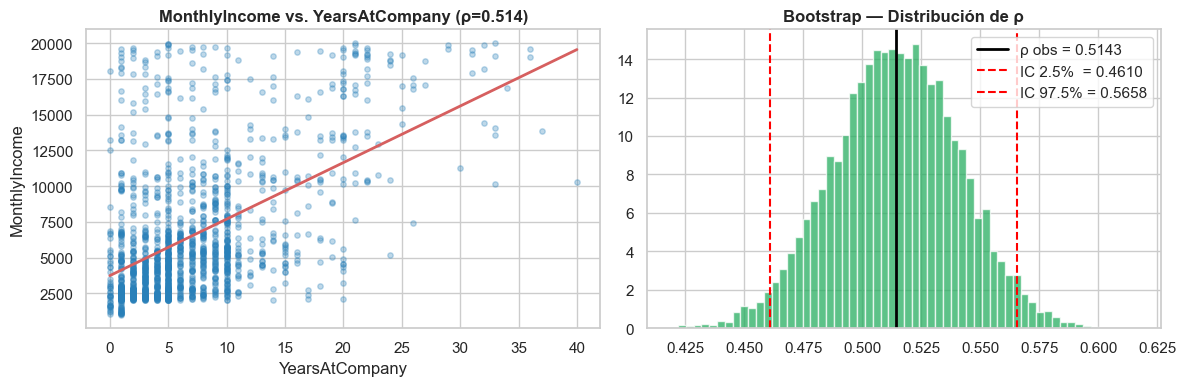

In [125]:
np.random.seed(42)
B = 9_999
income_arr = df['MonthlyIncome'].values

# IC percentil clásico para la MEDIA (comparar con IC paramétrico)
boot_medias = np.array([np.mean(np.random.choice(income_arr, len(income_arr), replace=True))
                         for _ in range(B)])
ic_boot_media = np.percentile(boot_medias, [2.5, 97.5])

print("a) IC Bootstrap (percentil) vs. Paramétrico — Media MonthlyIncome")
print(f"   IC Bootstrap 95%  = [${ic_boot_media[0]:,.2f}, ${ic_boot_media[1]:,.2f}]")
print(f"   IC Paramétrico 95%  = [${ic95_scipy[0]:,.2f}, ${ic95_scipy[1]:,.2f}]")
print(f"   Son muy similares (n=1470 es grande; TLC aplica bien).")
print(f"   Preferiría bootstrap cuando la distribución es muy sesgada o n pequeño.")

# c) Bootstrap para correlación MonthlyIncome ~ YearsAtCompany
corr_obs = df['MonthlyIncome'].corr(df['YearsAtCompany'])
idx_all = np.arange(len(df))
boot_corrs = np.array([
    pd.Series(df['MonthlyIncome'].values[np.random.choice(idx_all, len(idx_all), replace=True)]).corr(
    pd.Series(df['YearsAtCompany'].values[np.random.choice(idx_all, len(idx_all), replace=True)]))
    for _ in range(B)
])
# Correct bootstrap: same index for both
boot_corrs = np.array([
    np.corrcoef(
        df['MonthlyIncome'].values[s:=np.random.choice(idx_all, len(idx_all), replace=True)],
        df['YearsAtCompany'].values[s]
    )[0,1] for _ in range(B)
])
ic_corr = np.percentile(boot_corrs, [2.5, 97.5])

print(f"\nc) Correlación de Pearson — MonthlyIncome vs. YearsAtCompany")
print(f"   ρ observado  = {corr_obs:.4f}")
print(f"   IC 95% boot  = [{ic_corr[0]:.4f}, {ic_corr[1]:.4f}]")
print(f"   ¿Contiene el cero? {'Sí' if ic_corr[0]<=0<=ic_corr[1] else 'No → correlación significativa'}")

# Scatter
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(df['YearsAtCompany'], df['MonthlyIncome'],
                alpha=0.3, s=15, color='#2980b9')
m, b = np.polyfit(df['YearsAtCompany'], df['MonthlyIncome'], 1)
x_line = np.linspace(0, df['YearsAtCompany'].max(), 100)
axes[0].plot(x_line, m*x_line+b, 'r-', linewidth=2)
axes[0].set_title(f"MonthlyIncome vs. YearsAtCompany (ρ={corr_obs:.3f})", fontweight='bold')
axes[0].set_xlabel("YearsAtCompany"); axes[0].set_ylabel("MonthlyIncome")

axes[1].hist(boot_corrs, bins=60, density=True, color='#27ae60', alpha=0.75, edgecolor='white')
axes[1].axvline(corr_obs,      color='black', linewidth=2, label=f'ρ obs = {corr_obs:.4f}')
axes[1].axvline(ic_corr[0], color='red', linestyle='--', label=f'IC 2.5%  = {ic_corr[0]:.4f}')
axes[1].axvline(ic_corr[1], color='red', linestyle='--', label=f'IC 97.5% = {ic_corr[1]:.4f}')
axes[1].set_title("Bootstrap — Distribución de ρ", fontweight='bold')
axes[1].legend()
plt.tight_layout(); plt.show()


In [126]:
# para la media (MonthlyIncome)
theta_hat = income_arr.mean()
boot = boot_medias
prop_less = (boot < theta_hat).mean()
z0 = norm.ppf(prop_less)

n = len(income_arr)
jack_means = (income_arr.sum() - income_arr) / (n - 1)
jack_bar = jack_means.mean()
num = np.sum((jack_bar - jack_means) ** 3)
den = 6.0 * (np.sum((jack_bar - jack_means) ** 2) ** 1.5)
a = num / den if den != 0 else 0.0

def bca_alpha(alpha):
    z_alpha = norm.ppf(alpha)
    adj = z0 + (z0 + z_alpha) / (1 - a * (z0 + z_alpha))
    return norm.cdf(adj)

alpha_low = bca_alpha(0.025)
alpha_high = bca_alpha(0.975)
ic_bca = (np.quantile(boot, alpha_low), np.quantile(boot, alpha_high))

print("IC BCa 95% — Media MonthlyIncome")
print(f"  z0 = {z0:.4f}, a = {a:.6f}")
print(f"  IC BCa = [${ic_bca[0]:,.2f}, ${ic_bca[1]:,.2f}]")

IC BCa 95% — Media MonthlyIncome
  z0 = 0.0024, a = 0.005949
  IC BCa = [$6,270.21, $6,750.83]


---
## 10. Resumen de Fórmulas y Hallazgos Principales

| Concepto | Fórmula |
|----------|---------|
| Prob. conjunta | $P(A \cap B) = n(A\cap B)/N$ |
| Prob. marginal | $P(A) = \sum_j P(A \cap B_j)$ |
| Prob. condicional | $P(A\|B) = P(A\cap B)/P(B)$ |
| Probabilidad total | $P(A) = \sum_i P(A\|B_i)P(B_i)$ |
| Teorema de Bayes | $P(B_i\|A) = P(A\|B_i)P(B_i)/\sum_j P(A\|B_j)P(B_j)$ |
| TLC | $\bar{X}_n \sim \dot{N}(\mu,\,\sigma^2/n)$ |
| IC para µ | $\bar{X} \pm z_{\alpha/2}\, S/\sqrt{n}$ |
| IC para p | $\hat{p} \pm z_{\alpha/2}\sqrt{\hat{p}(1-\hat{p})/n}$ |
| Estadístico t | $t = (\bar{X}_1-\bar{X}_2)/\sqrt{S_1^2/n_1+S_2^2/n_2}$ |
| Estadístico χ² | $\chi^2 = \sum(O_{ij}-E_{ij})^2/E_{ij}$ |
| Bootstrap SE | $SE_{boot} = \sqrt{\frac{1}{B-1}\sum(\hat{\theta}^*_b-\bar{\hat{\theta}}^*)^2}$ |


In [127]:
# Resumen ejecutivo de todos los hallazgos
print("=" * 65)
print("       RESUMEN EJECUTIVO — HALLAZGOS DEL TALLER")
print("=" * 65)
print(f"\n  Dataset: {len(df):,} empleados, tasa de desercion = {p_hat_att:.1%}")
print(f"\n  OverTime: P(Att=Yes|OT=Yes) = {p_att_yes_given_ot_yes:.3f} vs. {p_att_yes_given_ot_no:.3f}")
print(f"     Hacer OverTime suma +{(p_att_yes_given_ot_yes-p_att_yes_given_ot_no)*100:.1f}pp de riesgo")
print(f"\n  Ingreso: quienes desertan ganan ${inc_yes_.mean():,.0f} vs ${inc_no_.mean():,.0f}")
print("     Diferencia estadisticamente significativa (p<0.001)")
print(f"\n  TLC verificado: para n≥30, X̄ se aproxima bien a N(µ, σ²/n)")
print(f"\n  Bootstrap mediana: IC 95% = [${ic_boot[0]:,.0f}, ${ic_boot[1]:,.0f}]")
print(f"\n  Correlacion MonthlyIncome~YearsAtCompany: ρ={corr_obs:.3f}")


       RESUMEN EJECUTIVO — HALLAZGOS DEL TALLER

  Dataset: 1,470 empleados, tasa de desercion = 16.1%

  OverTime: P(Att=Yes|OT=Yes) = 0.305 vs. 0.104
     Hacer OverTime suma +20.1pp de riesgo

  Ingreso: quienes desertan ganan $4,787 vs $6,833
     Diferencia estadisticamente significativa (p<0.001)

  TLC verificado: para n≥30, X̄ se aproxima bien a N(µ, σ²/n)

  Bootstrap mediana: IC 95% = [$4,738, $5,150]

  Correlacion MonthlyIncome~YearsAtCompany: ρ=0.514


## Referencias
1. Dataset: https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset